# Bike Sales prediction using Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error,accuracy_score


In [2]:
df=pd.read_csv(r"C:\Users\LENOVO\Downloads\bike_sales_raw.csv")#load data
df.head()

,sale_id,date,brand,category,manufacture_year,price,discount_pct,rating,region,units_sold
0,1,2023-04-13,RidgeRacer,Road,2020.0,650.89,17.85,3.67,North,24
1,2,2024-03-11,TrailPro,Hybrid,2023.0,610.72,10.34,3.89,East,28
2,3,2023-09-28,RidgeRacer,Hybrid,2015.0,432.24,6.80,3.06,Central,29
3,4,2023-04-17,CityGlide,Hybrid,2024.0,661.25,5.55,3.97,East,25
4,5,2023-03-13,TrailPro,Mountain,2021.0,577.67,5.74,4.17,Central,28


In [3]:
df.isnull().sum()

sale_id              0
date                 0
brand                0
category             0
manufacture_year    19
price               27
discount_pct        53
rating              29
region               0
units_sold           0
dtype: int64

In [4]:
x1=df['manufacture_year'].median()
x1

2020.0

In [5]:
x2=df['price'].mean()
x2

np.float64(721.6483003655385)

In [6]:
x3=df['discount_pct'].mean()
x4=df['rating'].mean()

In [7]:
df['manufacture_year'].fillna(x1,inplace=True)#handling missing values
df['price'].fillna(x2,inplace=True)
df['discount_pct'].fillna(x3,inplace=True)
df['rating'].fillna(x4,inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10288\1154199891.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['manufacture_year'].fillna(x1,inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10288\1154199891.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [8]:
df.isnull().sum()

sale_id             0
date                0
brand               0
category            0
manufacture_year    0
price               0
discount_pct        0
rating              0
region              0
units_sold          0
dtype: int64

In [9]:
df=pd.get_dummies(df,columns=['brand','category','region'], drop_first=True)#using onehot encoding
df

,sale_id,date,manufacture_year,price,discount_pct,rating,units_sold,brand_ElectraX,brand_RidgeRacer,brand_TrailPro,brand_Velox,category_Hybrid,category_Mountain,category_Road,region_East,region_North,region_South,region_West
0,1,2023-04-13,2020.0,650.890000,17.85,3.67,24,False,True,False,False,False,False,True,False,True,False,False
1,2,2024-03-11,2023.0,610.720000,10.34,3.89,28,False,False,True,False,True,False,False,True,False,False,False
2,3,2023-09-28,2015.0,432.240000,6.80,3.06,29,False,True,False,False,True,False,False,False,False,False,False
3,4,2023-04-17,2024.0,661.250000,5.55,3.97,25,False,False,False,False,True,False,False,True,False,False,False
4,5,2023-03-13,2021.0,577.670000,5.74,4.17,28,False,False,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-03-30,2016.0,1102.320000,12.09,3.83,22,False,False,False,True,False,False,False,False,False,False,True
996,997,2024-02-06,2021.0,3577.214667,9.67,3.73,26,True,False,False,False,True,False,False,False,False,True,False
997,998,2023-10-23,2019.0,1312.040000,17.27,4.56,20,False,True,False,False,False,False,False,True,False,False,False
998,999,2023-10-22,2020.0,671.850000,6.33,3.35,25,False,False,False,True,False,False,True,False,True,False,False


# Feature Engineering

In [10]:
df['date']=pd.to_datetime(df['date'])
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month
df['day']=df['date'].dt.day
df

,sale_id,date,manufacture_year,price,discount_pct,rating,units_sold,brand_ElectraX,brand_RidgeRacer,brand_TrailPro,...,category_Hybrid,category_Mountain,category_Road,region_East,region_North,region_South,region_West,year,month,day
0,1,2023-04-13,2020.0,650.890000,17.85,3.67,24,False,True,False,...,False,False,True,False,True,False,False,2023,4,13
1,2,2024-03-11,2023.0,610.720000,10.34,3.89,28,False,False,True,...,True,False,False,True,False,False,False,2024,3,11
2,3,2023-09-28,2015.0,432.240000,6.80,3.06,29,False,True,False,...,True,False,False,False,False,False,False,2023,9,28
3,4,2023-04-17,2024.0,661.250000,5.55,3.97,25,False,False,False,...,True,False,False,True,False,False,False,2023,4,17
4,5,2023-03-13,2021.0,577.670000,5.74,4.17,28,False,False,True,...,False,True,False,False,False,False,False,2023,3,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-03-30,2016.0,1102.320000,12.09,3.83,22,False,False,False,...,False,False,False,False,False,False,True,2023,3,30
996,997,2024-02-06,2021.0,3577.214667,9.67,3.73,26,True,False,False,...,True,False,False,False,False,True,False,2024,2,6
997,998,2023-10-23,2019.0,1312.040000,17.27,4.56,20,False,True,False,...,False,False,False,True,False,False,False,2023,10,23
998,999,2023-10-22,2020.0,671.850000,6.33,3.35,25,False,False,False,...,False,False,True,False,True,False,False,2023,10,22


In [12]:
relation = df.corr()
relation

,sale_id,date,manufacture_year,price,discount_pct,rating,units_sold,brand_ElectraX,brand_RidgeRacer,brand_TrailPro,...,category_Hybrid,category_Mountain,category_Road,region_East,region_North,region_South,region_West,year,month,day
sale_id,1.000000,-0.038930,0.011508,0.055709,0.008038,-0.002451,0.057042,-0.009808,-0.008265,-0.000751,...,-0.044160,-0.004211,0.039218,-0.014369,-0.030456,0.044355,0.044190,-0.046707,0.000883,0.040109
date,-0.038930,1.000000,-0.005380,0.026890,-0.019336,-0.032062,0.027819,0.024662,-0.071856,0.027098,...,-0.000857,-0.026995,-0.009773,-0.062191,0.070818,-0.020280,0.026327,0.870210,0.470494,0.091189
manufacture_year,0.011508,-0.005380,1.000000,0.145467,-0.006905,0.002828,0.042363,-0.031794,0.049716,-0.072634,...,0.000668,-0.026460,0.077842,0.027042,-0.004606,-0.022316,0.041374,-0.007673,0.004711,-0.021656
price,0.055709,0.026890,0.145467,1.000000,-0.008924,-0.016349,-0.079641,0.191534,0.052993,-0.088703,...,-0.283728,-0.225792,-0.061854,0.030955,0.005582,-0.028722,-0.008412,0.028827,0.004380,-0.018086
discount_pct,0.008038,-0.019336,-0.006905,-0.008924,1.000000,0.019748,0.003296,-0.009527,0.018472,-0.034318,...,0.004184,0.008886,-0.019632,0.029779,-0.068877,0.024110,0.008084,-0.018223,-0.005783,-0.010984
rating,-0.002451,-0.032062,0.002828,-0.016349,0.019748,1.000000,0.029190,0.028264,0.034883,0.007451,...,0.003764,0.012779,0.027403,0.004616,0.050444,-0.030298,-0.002840,-0.020664,-0.026587,-0.018385
units_sold,0.057042,0.027819,0.042363,-0.079641,0.003296,0.029190,1.000000,0.010259,0.015537,-0.021023,...,0.081373,0.023077,-0.031046,-0.006993,0.048237,0.016516,-0.029619,0.013448,0.034172,-0.018483
brand_ElectraX,-0.009808,0.024662,-0.031794,0.191534,-0.009527,0.028264,0.010259,1.000000,-0.243911,-0.217536,...,0.032821,-0.033874,-0.011265,-0.057507,0.033825,0.035538,-0.014987,0.013761,0.025917,-0.002495
brand_RidgeRacer,-0.008265,-0.071856,0.049716,0.052993,0.018472,0.034883,0.015537,-0.243911,1.000000,-0.278562,...,-0.007836,0.005524,-0.025267,-0.001833,-0.016402,-0.003047,0.040678,-0.074106,-0.009354,-0.051177
brand_TrailPro,-0.000751,0.027098,-0.072634,-0.088703,-0.034318,0.007451,-0.021023,-0.217536,-0.278562,1.000000,...,-0.029764,0.036680,-0.004281,0.009982,-0.008384,-0.001368,-0.020890,0.054545,-0.044970,0.029127


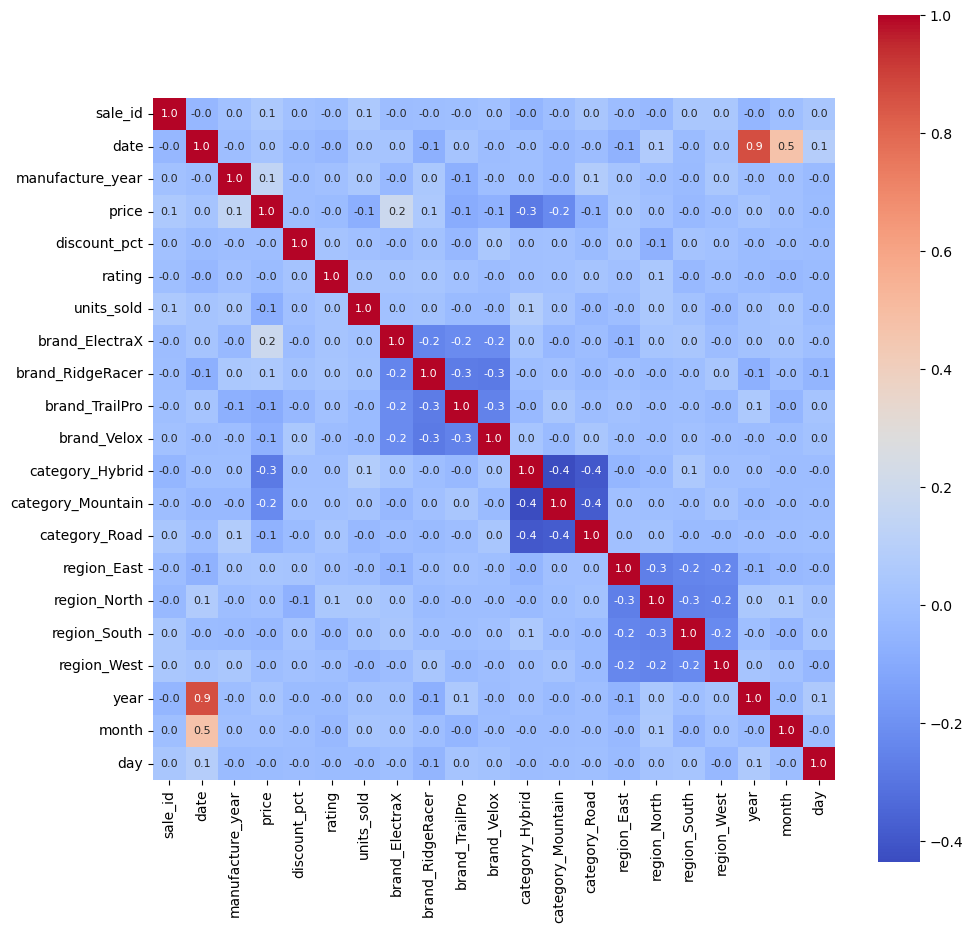

In [13]:
import seaborn as sns
plt.figure(figsize=(11,11))
sns.heatmap(relation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='coolwarm')
plt.show()

# Model Building

In [14]:
x=df.drop(['date','price'],axis=1)
y=df['price']
Xtrain,Xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
model=LinearRegression()
model.fit(Xtrain,ytrain)

LinearRegression()

In [16]:
pre=model.predict(Xtest)
pre

array([ 527.83457524,  670.33329906,  703.01983385,  627.05909939,
        656.80411508,  717.13734607,  589.97286137,  542.84586116,
        602.62959477,  580.78054613,  826.9246603 , 1202.33655701,
        761.41969495,  709.54477221,  612.46869097, 1331.93912799,
        649.38458877,  629.27245253,  650.01833296,  548.30495707,
        628.2901224 ,  655.61300576,  619.53561623,  611.23460056,
        618.6710356 ,  658.67725322,  693.12834572,  776.37543037,
        559.23624983,  787.3234227 ,  527.68089782,  590.6789707 ,
        751.1017254 ,  782.77079238, 1274.31202752,  730.51978247,
        700.78422352,  783.16932188,  536.56020899,  619.18810236,
        566.62584301,  650.46962935,  511.66790471,  685.5944203 ,
        578.15392908,  727.42525023,  500.59037727,  615.92350605,
        543.22885765, 1195.33892247,  588.21884874,  473.3751481 ,
        543.48409507,  667.82883065,  571.05328252,  674.71081452,
       1284.77487549,  561.9157636 ,  627.2825659 ,  737.96312

In [17]:
ytest

521    484.43
737    693.18
740    631.53
660    608.47
411    650.19
        ...  
408    683.17
332    786.33
208    608.07
613    459.20
78     689.94
Name: price, Length: 200, dtype: float64

# Error Metrics

In [21]:
mse=mean_squared_error(ytest,pre)
print("MSE",mse)
print('RMSE',np.sqrt(mse))
r2=r2_score(ytest,pre)
print("r_square",r2)



MSE 57501.324577664236
RMSE 239.7943380850854
r_square 0.4351152205501394
